# Bone Fracture Detection Using YOLO

### Zhui Geng, Jackie Niu, Yufei Shen

#### Import libraries

In [18]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
import cv2
import random
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

#### Extract data

In [10]:
BASE_PATH = "../BoneFractureYolo8"

train_images = os.path.join(BASE_PATH, "train", "images")
train_labels = os.path.join(BASE_PATH, "train", "labels")

val_images = os.path.join(BASE_PATH, "valid", "images")
val_labels = os.path.join(BASE_PATH, "valid", "labels")

test_images = os.path.join(BASE_PATH, "test", "images")
test_labels = os.path.join(BASE_PATH, "test", "labels")

In [11]:
print('Number of train frames: ' + str(len(os.listdir(train_images))))
print('Number of train labels: ' + str(len(os.listdir(train_labels))))
print('Number of val frames: ' + str(len(os.listdir(val_images))))
print('Number of val labels: ' + str(len(os.listdir(val_labels))))
print('Number of test frames: ' + str(len(os.listdir(test_images))))
print('Number of test labels: ' + str(len(os.listdir(test_labels))))
print('Total frames: ' + str(len(os.listdir(train_images)) + len(os.listdir(test_images)) + len(os.listdir(val_images))))

Number of train frames: 3631
Number of train labels: 3631
Number of val frames: 348
Number of val labels: 348
Number of test frames: 169
Number of test labels: 169
Total frames: 4148


#### Visualize images with fracture annotations

Labels use the **OBB (Oriented Bounding Box)** format:  
`class x1 y1 x2 y2 x3 y3 x4 y4`  (all coordinates normalized 0–1)

The 7 fracture classes are:
- 0: elbow positive
- 1: fingers positive
- 2: forearm fracture
- 3: humerus fracture
- 4: humerus
- 5: shoulder fracture
- 6: wrist positive

In [14]:
CLASS_NAMES = [
    'elbow positive', 'fingers positive', 'forearm fracture',
    'humerus fracture', 'humerus', 'shoulder fracture', 'wrist positive'
]

# Using one distinct RGB colour per class (values 0-1)
CLASS_COLORS = [
    (1.00, 0.39, 0.28),   # 0  elbow positive      
    (1.00, 0.65, 0.00),   # 1  fingers positive    
    (0.20, 0.80, 0.20),   # 2  forearm fracture   
    (0.12, 0.56, 1.00),   # 3  humerus fracture   
    (0.58, 0.00, 0.83),   # 4  humerus            
    (1.00, 0.08, 0.58),   # 5  shoulder fracture   
    (0.00, 0.81, 0.82),   # 6  wrist positive      
]

In [20]:
def read_yolo_labels(label_path):
    # Reads YOLO format labels from a text file and returns a list of bounding boxes.
    boxes = []
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(float(parts[0]))
            xc, yc, w, h = map(float, parts[1:5])
            boxes.append((cls, xc, yc, w, h))
    return boxes

In [21]:
def yolo_to_xyxy(xc, yc, w, h, img_w, img_h):
    # Convert normalized YOLO bbox to pixel coords (x1,y1,x2,y2)
    
    x1 = (xc - w/2) * img_w
    y1 = (yc - h/2) * img_h
    x2 = (xc + w/2) * img_w
    y2 = (yc + h/2) * img_h

    # clamp
    x1 = max(0, min(img_w - 1, x1))
    y1 = max(0, min(img_h - 1, y1))
    x2 = max(0, min(img_w - 1, x2))
    y2 = max(0, min(img_h - 1, y2))
    return x1, y1, x2, y2

In [22]:
def plot_samples_with_boxes(images_dir, labels_dir, n=16, seed=42):
    img_files = [f for f in os.listdir(images_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]

    if len(img_files) == 0:
        raise FileNotFoundError(f"No images found in: {images_dir}")

    random.seed(seed)
    sample_files = random.sample(img_files, k=min(n, len(img_files)))

    cols = 4
    rows = int(np.ceil(len(sample_files) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 16))
    axes = axes.flatten()

    for i, ax in enumerate(axes):
        ax.axis("off")
        if i >= len(sample_files):
            continue

        img_name = sample_files[i]
        img_path = os.path.join(images_dir, img_name)

        # read image (cv2 -> BGR), convert to RGB for matplotlib
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            ax.set_title(f"Could not read: {img_name}", fontsize=9)
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        H, W = img_rgb.shape[:2]

        # corresponding label file
        label_name = os.path.splitext(img_name)[0] + ".txt"
        label_path = os.path.join(labels_dir, label_name)
        boxes = read_yolo_labels(label_path)

        ax.imshow(img_rgb)
        ax.set_title(img_name, fontsize=9)

        for (cls, xc, yc, w, h) in boxes:
            x1, y1, x2, y2 = yolo_to_xyxy(xc, yc, w, h, W, H)

            # pick color + label
            color = CLASS_COLORS[cls] if cls < len(CLASS_COLORS) else (0, 1, 0)
            label = CLASS_NAMES[cls] if cls < len(CLASS_NAMES) else str(cls)

            rect = mpatches.Rectangle(
                (x1, y1),
                x2 - x1,
                y2 - y1,
                fill=False,
                linewidth=2,
                edgecolor=color
            )
            ax.add_patch(rect)

            ax.text(
                x1,
                max(0, y1 - 6),
                label,
                fontsize=8,
                color="black",
                bbox=dict(facecolor=color, alpha=0.8, pad=1, edgecolor="none")
            )

    plt.tight_layout()
    plt.show()


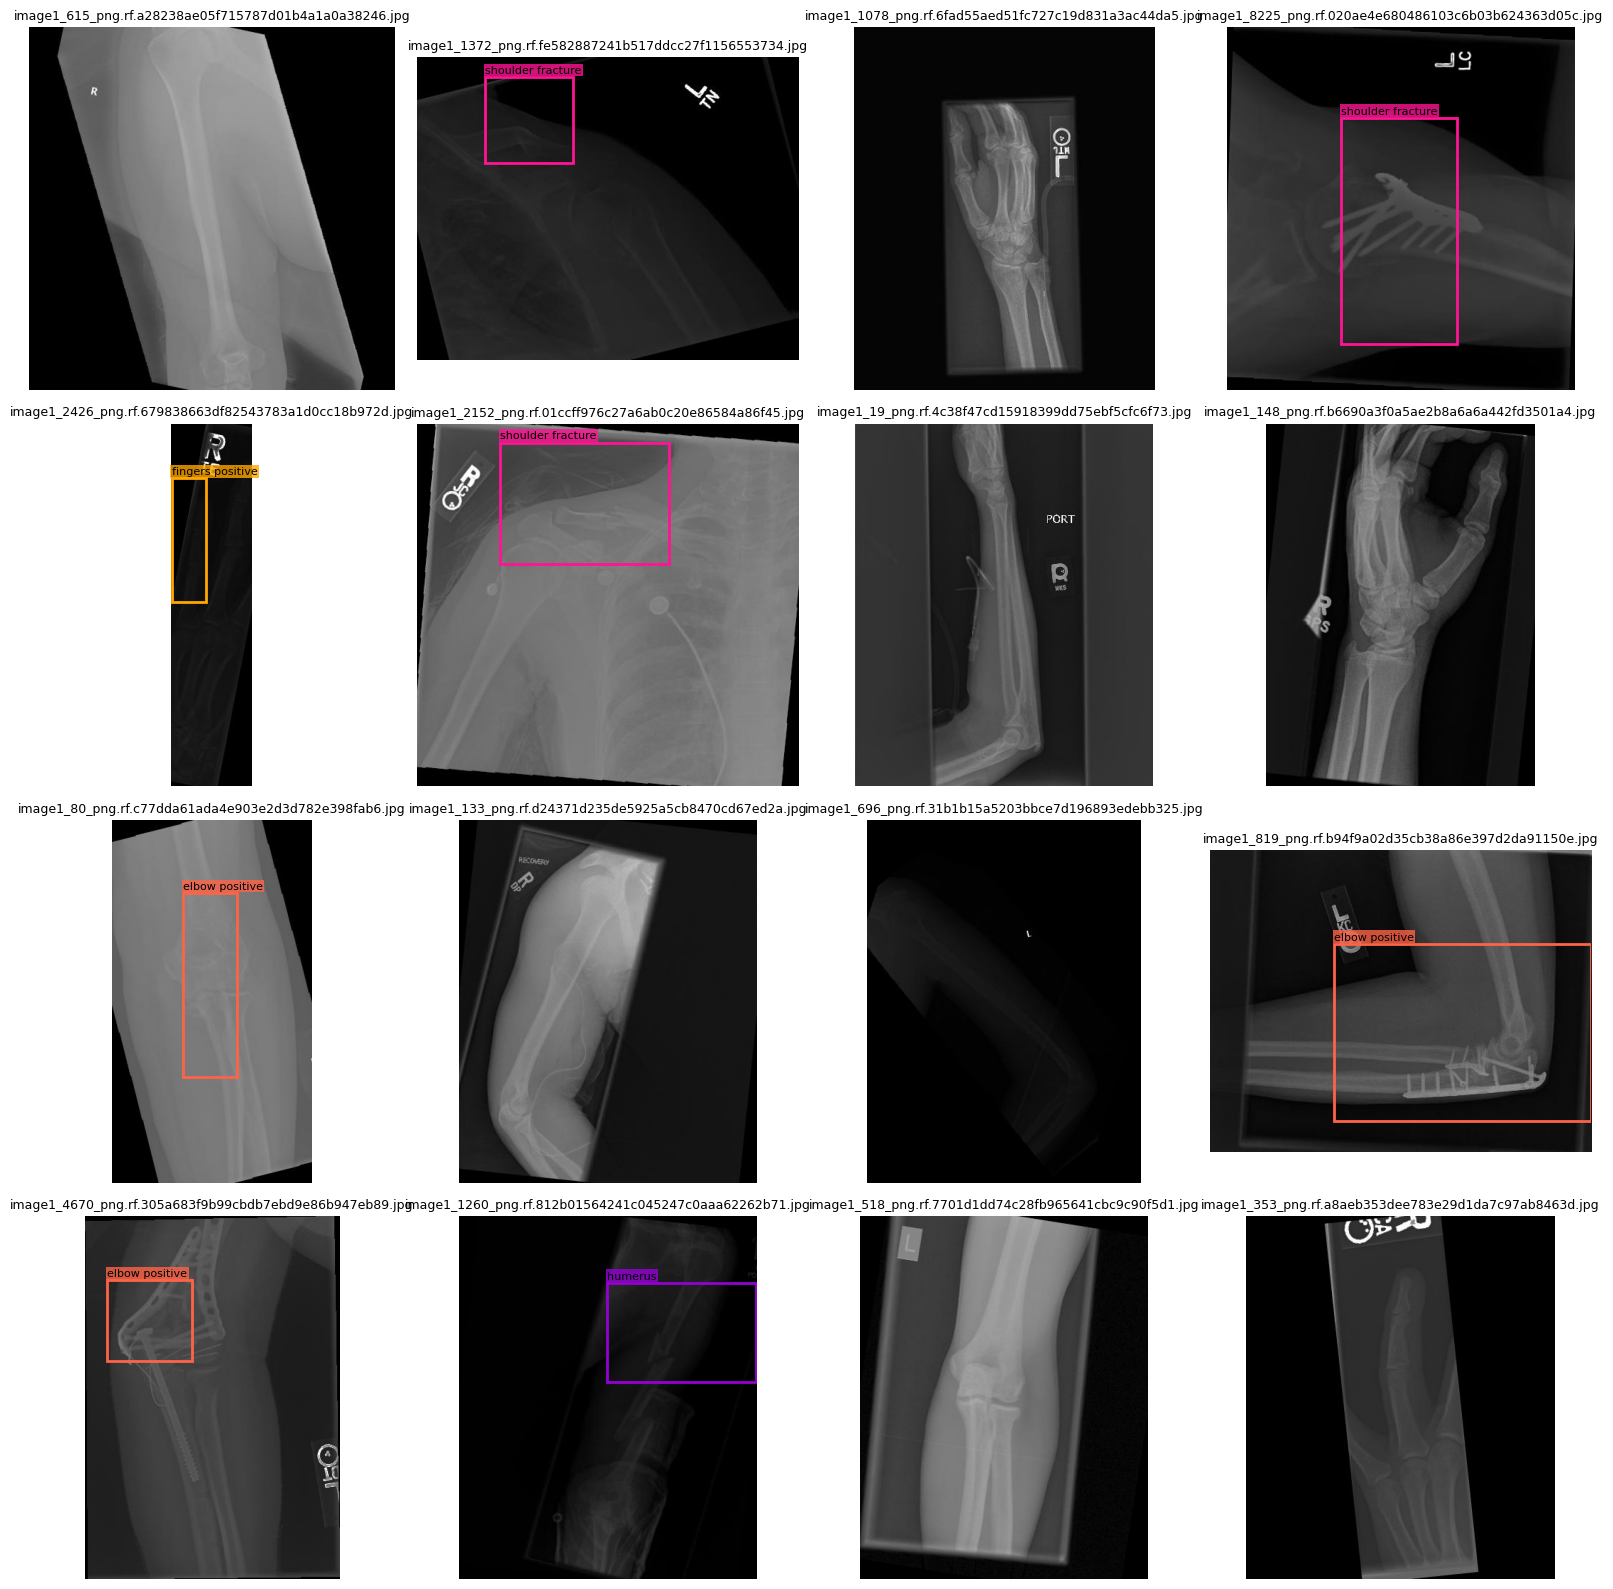

In [24]:
plot_samples_with_boxes(train_images, train_labels, n=16, seed=42)